# Simulation

Step 8.3. The lap session of `track_following.ipynb` in Gazebo: the same EKF, AMCL and Pure
Pursuit with the same parameters, on sim time, with the sim_car plugin in place of the ESP32
and the car (`docs/simulation.md`). Three laps at 60% of the speed profile and three at full
speed, against the real runs. The sim also knows where the car is (`/ground_truth`), which the
real runs could not measure.

Step 8.4. The drift of Phase 5 replayed against the real one, then the floor friction changed
(`mu_scale` of sim_car) under the drift and under the laps.

In [1]:
import sys
sys.path.append('../scripts')
sys.path.append('../ros2_ws/src/ackermann_control')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
import bagtools as bt
from ackermann_control.pure_pursuit import lateral_error, load_track, nearest

plt.rcParams['figure.dpi'] = 72
track = load_track('../ros2_ws/src/ackermann_bringup/maps/room_track.csv')
room = yaml.safe_load(open('../ros2_ws/src/ackermann_bringup/maps/room.yaml'))
room_img = np.array(Image.open('../ros2_ws/src/ackermann_bringup/maps/room.pgm'))

/home/pietro/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Laps

As in `track_following.ipynb`: the rear axle as the controller sees it (`bt.map_pose`), lateral
error to the nearest track point from 1 s after the start. For the sim runs the same error from
the true pose, and the distance between the two: the localization error. The truth is taken at
the stamp of the EKF pose, 4-16 ms before it reaches the bag.

In [2]:
def follow(t, X, Y):
    # lateral error [cm]; lap times from the nearest track point wrapping to the first quarter
    idx, e, i = [], [], None
    for x, y in zip(X, Y):
        i = nearest(track, x, y, i)
        idx.append(i)
        e.append(lateral_error(track, i, x, y))
    idx, e = np.array(idx), np.array(e) * 100
    n = len(track)
    crossings = t[1:][(idx[:-1] > 3 * n // 4) & (idx[1:] < n // 4)]
    return e, np.diff(crossings)


def rms(x):
    return np.sqrt(np.mean(x ** 2))


runs, rows = {}, []
for name in ['pp_run1', 'sim_pp_60', 'pp_run3', 'pp_video', 'sim_pp_full']:
    d = bt.load(f'../data/{name}_parquet')
    t, X, Y = bt.map_pose(d)
    js = d['joint_states']
    moving = js['t'][js[['wl', 'wr']].abs().max(axis=1) > 1.0]
    w = (t > moving.iloc[0] + 1.0) & (t < moving.iloc[-1])
    t, X, Y = t[w], X[w], Y[w]
    e, laps = follow(t, X, Y)
    row = {'run': name, 'speed': d['drive']['cmd_speed'].max(), 'lap times [s]': ', '.join(f'{x:.1f}' for x in laps),
           'error rms [cm]': rms(e), 'error max [cm]': np.abs(e).max()}
    runs[name] = {'t': t - t[0], 'X': X, 'Y': Y, 'e': e}
    if 'ground_truth' in d:
        o, g = d['odometry_filtered'], d['ground_truth']
        stamp = np.interp(t, o['t'], o['stamp'])
        gx, gy = np.interp(stamp, g['stamp'], g['x']), np.interp(stamp, g['stamp'], g['y'])
        e_true, _ = follow(t, gx, gy)
        pose = np.hypot(X - gx, Y - gy) * 100
        row.update({'true error rms [cm]': rms(e_true), 'true error max [cm]': np.abs(e_true).max(),
                    'localization rms [cm]': rms(pose), 'localization max [cm]': pose.max()})
        runs[name].update({'gx': gx, 'gy': gy, 'e_true': e_true, 'stop': g.iloc[-1]})
    rows.append(row)
pd.DataFrame(rows).round(2)

,run,speed,lap times [s],error rms [cm],error max [cm],true error rms [cm],true error max [cm],localization rms [cm],localization max [cm]
0,pp_run1,0.6,"17.1, 17.2",1.78,5.11,NaN,NaN,NaN,NaN
1,sim_pp_60,0.6,"16.9, 16.7",3.64,9.52,4.06,10.08,6.23,9.95
2,pp_run3,1.0,"10.2, 10.1",2.70,6.30,NaN,NaN,NaN,NaN
3,pp_video,1.0,"10.1, 10.2",2.59,6.83,NaN,NaN,NaN,NaN
4,sim_pp_full,1.0,"10.1, 10.2",4.41,11.08,4.65,11.11,5.71,13.47


In [3]:
for name in ['sim_pp_60', 'sim_pp_full']:
    s = runs[name]['stop']
    print(f"{name}: stops {np.hypot(s['x'] - track['x'][0], s['y'] - track['y'][0]) * 100:.0f} cm from the start of the track")

sim_pp_60: stops 9 cm from the start of the track
sim_pp_full: stops 21 cm from the start of the track


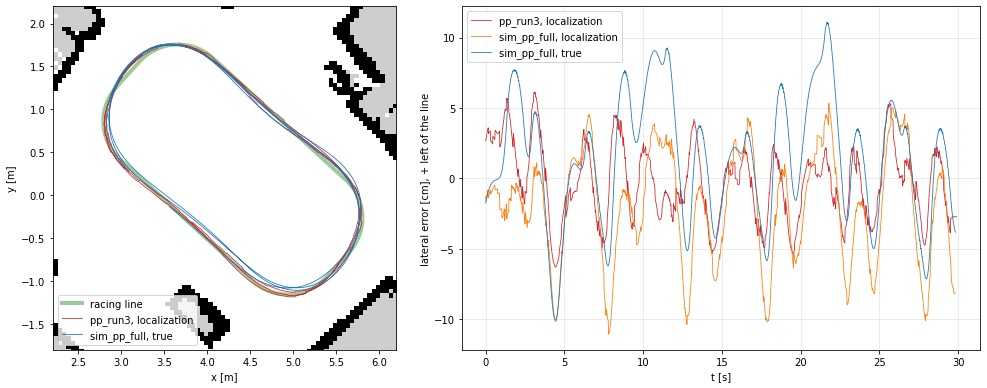

In [4]:
res, (x0, y0) = room['resolution'], room['origin'][:2]
h, w = room_img.shape
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.4]})
ax[0].imshow(room_img, cmap='gray', extent=[x0, x0 + w * res, y0, y0 + h * res])
ax[0].plot(track['x'], track['y'], 'g', lw=4, alpha=0.4, label='racing line')
ax[0].plot(runs['pp_run3']['X'], runs['pp_run3']['Y'], 'C3', lw=0.8, label='pp_run3, localization')
ax[0].plot(runs['sim_pp_full']['gx'], runs['sim_pp_full']['gy'], 'C0', lw=0.8, label='sim_pp_full, true')
ax[0].set_xlim(2.2, 6.2)
ax[0].set_ylim(-1.8, 2.2)
ax[0].set_xlabel('x [m]')
ax[0].set_ylabel('y [m]')
ax[0].legend(loc='lower left')
ax[1].plot(runs['pp_run3']['t'], runs['pp_run3']['e'], 'C3', lw=0.8, label='pp_run3, localization')
ax[1].plot(runs['sim_pp_full']['t'], runs['sim_pp_full']['e'], 'C1', lw=0.8, label='sim_pp_full, localization')
ax[1].plot(runs['sim_pp_full']['t'], runs['sim_pp_full']['e_true'], 'C0', lw=0.8, label='sim_pp_full, true')
ax[1].set_xlabel('t [s]')
ax[1].set_ylabel('lateral error [cm], + left of the line')
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()

## Corners

On the arcs of the track (curvature 1/0.6 m): the mean steering command and the yaw rate from
the gyro. The two real runs at full speed are pooled.

In [5]:
rows = []
for names in [['pp_run1'], ['sim_pp_60'], ['pp_run3', 'pp_video'], ['sim_pp_full']]:
    cmd, gz = [], []
    for name in names:
        d = bt.load(f'../data/{name}_parquet')
        t, X, Y = bt.map_pose(d)
        idx, i = [], None
        for x, y in zip(X, Y):
            i = nearest(track, x, y, i)
            idx.append(i)
        arc = (track['kappa'][np.array(idx)] > 1.5).astype(float)
        dr, im = d['drive'], d['imu_data_raw']
        cmd.append(dr['cmd_steer'][(np.interp(dr['t'], t, arc) == 1) & (dr['cmd_speed'] > 0.1)])
        gz.append(im['gz'][np.interp(im['t'], t, arc) == 1])
    rows.append({'run': ' + '.join(names), 'steer cmd [rad]': np.mean(np.concatenate(cmd)),
                 'yaw rate [rad/s]': np.mean(np.concatenate(gz))})
pd.DataFrame(rows).round(3)

,run,steer cmd [rad],yaw rate [rad/s]
0,pp_run1,0.262,0.648
1,sim_pp_60,0.278,0.606
2,pp_run3 + pp_video,0.251,1.026
3,sim_pp_full,0.250,0.982


## Drift

The /drive of the drift runs replayed open loop (`scripts/sim_replay.py`): 0.9 m/s at full left
lock, then 1.3 m/s, then 0.6. The real sideslip is from the overhead video
(`system_identification.ipynb`), the sim one from /ground_truth. Means over the steady donut,
from 2 s after the 1.3 m/s step to its end.

In [6]:
def replay(run, mu='1.00'):
    real = pd.read_parquet(f'../data/sysid/{run}.parquet')
    sim = pd.read_parquet(f'../data/sim_replay/{run}_mu{mu}.parquet')
    out = {}
    for topic in ['gyro_z', 'beta_cg', 'beta_rear', 'wheel']:
        s = sim[sim['topic'] == topic].sort_values('t')
        out[topic] = np.interp(real['t'], s['t'], s['value'])
    out['wheel'] = out['wheel'] * 0.0299
    return real, out


def donut(real):
    cmd = real['cmd_speed'].ffill()
    return (cmd > 1.2) & (real['t'] > real['t'][cmd > 1.2].min() + 2)


rows = []
for run in ['id_drift', 'val_drift']:
    real, sim = replay(run)
    w = donut(real)
    for label, r, b_cg, b_rear, v in [('real', real['r'], real['beta_cg'], real['beta_rear'], real['v_wheels']),
                                      ('sim', sim['gyro_z'], sim['beta_cg'], sim['beta_rear'], sim['wheel'])]:
        rows.append({'run': run, '': label, 'yaw rate [rad/s]': np.nanmean(r[w]), 'beta cg [deg]': np.nanmean(b_cg[w]),
                     'beta rear [deg]': np.nanmean(b_rear[w]), 'wheel speed [m/s]': np.nanmean(v[w])})
pd.DataFrame(rows).round(2)

,run,,yaw rate [rad/s],beta cg [deg],beta rear [deg],wheel speed [m/s]
0,id_drift,real,3.56,-21.19,-43.57,1.12
1,id_drift,sim,4.08,-23.96,-49.72,1.20
2,val_drift,real,3.54,-17.99,-40.53,1.12
3,val_drift,sim,4.07,-23.95,-49.71,1.20


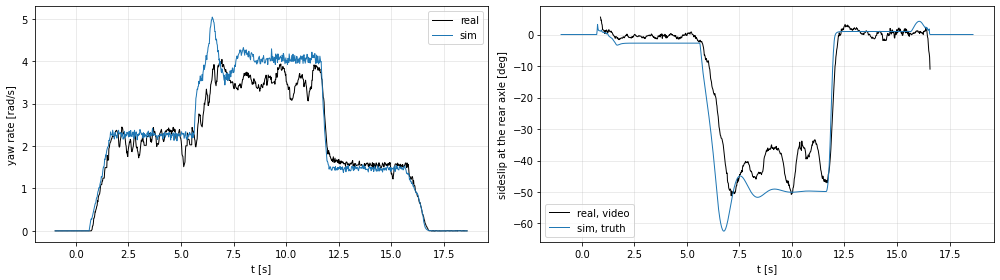

In [7]:
real, sim = replay('val_drift')
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(real['t'], real['r'], 'k', lw=1, label='real')
ax[0].plot(real['t'], sim['gyro_z'], 'C0', lw=1, label='sim')
ax[0].set_ylabel('yaw rate [rad/s]')
ax[1].plot(real['t'], real['beta_rear'], 'k', lw=1, label='real, video')
ax[1].plot(real['t'], sim['beta_rear'], 'C0', lw=1, label='sim, truth')
ax[1].set_ylabel('sideslip at the rear axle [deg]')
for a in ax:
    a.set_xlabel('t [s]')
    a.grid(alpha=0.3)
    a.legend()
plt.tight_layout()
plt.show()

## Friction

`mu_scale` scales the floor friction against the tiles: the peak tire force with it, the
stiffness at small slip unchanged (brush model). The val_drift replay at four values, then the
full speed laps of Pure Pursuit, tuned on the tiles, as the floor gets slipperier: three laps
take ~30 s, a shorter run is the node stopping 0.5 m off the line.

In [8]:
rows = []
real = pd.read_parquet('../data/sysid/val_drift.parquet')
cmd = real['cmd_speed'].ffill()
grip = (cmd > 0.85) & (cmd < 0.95)
for mu in ['0.70', '0.85', '1.00', '1.15']:
    _, sim = replay('val_drift', mu)
    w = donut(real)
    rows.append({'mu_scale': mu, 'yaw rate at 0.9 [rad/s]': np.mean(sim['gyro_z'][grip]),
                 'beta cg at 0.9 [deg]': np.mean(sim['beta_cg'][grip]),
                 'donut yaw rate [rad/s]': np.mean(sim['gyro_z'][w]), 'donut beta cg [deg]': np.mean(sim['beta_cg'][w]),
                 'donut beta rear [deg]': np.mean(sim['beta_rear'][w])})
pd.DataFrame(rows).round(2)

,mu_scale,yaw rate at 0.9 [rad/s],beta cg at 0.9 [deg],donut yaw rate [rad/s],donut beta cg [deg],donut beta rear [deg]
0,0.70,2.98,-6.29,3.50,-36.56,-59.67
1,0.85,2.23,8.88,3.82,-30.11,-54.86
2,1.00,2.26,10.29,4.07,-23.95,-49.71
3,1.15,2.26,10.97,4.26,-17.92,-43.87


In [9]:
rows = []
for name, mu in [('sim_pp_full', '1.00'), ('sim_pp_mu0.60', '0.60'), ('sim_pp_mu0.45', '0.45'),
                 ('sim_pp_mu0.35', '0.35'), ('sim_pp_mu0.25', '0.25'), ('sim_pp_mu0.20', '0.20')]:
    d = bt.load(f'../data/{name}_parquet')
    g = d['ground_truth']
    js = d['joint_states']
    moving = js['t'][js[['wl', 'wr']].abs().max(axis=1) > 1.0]
    g = g[(g['t'] > moving.iloc[0] + 1.0) & (g['t'] < moving.iloc[-1])]
    e, _ = follow(g['t'].to_numpy(), g['x'].to_numpy(), g['y'].to_numpy())
    fast = g[g['vx'] > 0.3]
    rear_slip = np.degrees(np.arctan2(fast['vy'], fast['vx']))    # the rear wheels do not steer
    rows.append({'mu_scale': mu, 'driven [s]': moving.iloc[-1] - moving.iloc[0],
                 'true error rms [cm]': rms(e), 'true error max [cm]': np.abs(e).max(),
                 'rear slip max [deg]': np.abs(rear_slip).max()})
pd.DataFrame(rows).round(1)

,mu_scale,driven [s],true error rms [cm],true error max [cm],rear slip max [deg]
0,1.00,30.8,4.7,11.1,3.5
1,0.60,30.6,4.8,12.6,6.1
2,0.45,30.8,6.0,22.5,8.4
3,0.35,30.9,7.6,28.1,13.2
4,0.25,6.2,20.5,41.8,62.3
5,0.20,6.4,27.3,61.1,62.5


## Result

**Laps.** The sim reproduces the session: lap times within 0.5 s (16.9 and 16.7 s against 17.1
and 17.2 at 60%, 10.1 and 10.2 at full speed as the real car), AMCL at the same 6.8 Hz with the
same spread, the stop 9-21 cm past the start line (10-15 cm real). It follows the line less
well: 3.6 and 4.4 cm rms against 1.8 and 2.7, 3-5 cm wide in every corner. There the sim car
turns 4-6% less: 0.98 against 1.03 rad/s at full speed with the same command, 0.61 against 0.65
at 60% with 6% more steering. The open loop replay of the steps shows the same deficit (6-9%,
`docs/simulation.md`): it comes from the Phase 5 model, not the loop. Only the sim can put the
pose the controller gets against the truth: 6 cm rms off, up to 10-13 cm. The lateral error
measured against the localization stays within 0.5 cm rms of the true one, so the metric of the
real runs does not hide a larger error at this level.

**Drift.** The sim goes into the same donut, deeper: 4.1 rad/s against 3.5, sideslip -24 deg
at the CG against -18/-21 and -50 at the rear axle against -41/-44. Its wheels spin at the
1.20 m/s free speed of the motor, the real ones at 1.12 under the load of the slide: the sim
has no motor torque limit, and 7% more wheel speed means more rear slip.

**Friction.** Less friction, deeper donut: -18 to -37 deg at the CG from mu_scale 1.15 to 0.70,
and at 0.70 the car already lets go at 0.9 m/s. Pure Pursuit with the speed profile of the
tiles keeps the laps down to 35% of their friction, the error growing from 4.7 to 7.6 cm rms
and the rear slip from 3.5 to 13 deg. At 25% and 20% the car fishtails on the first straight
and spins in the second corner, rear slip past 60 deg. The baseline does not know the
friction: Phases 10 and 11 add that.